# Heritability Enrichment

This notebooks show how to analyze heritability enrichment in functional annotations.

In [1]:
import sys
import os
import pandas as pd

In [2]:
sys.path.append(os.path.abspath("../.."))

In [3]:
from src.plot.heritability_plots import plot_h2, plot_enrichment_binary, plot_enrichment_continuous

After running D-LDSC in inference mode with the LDSC loss, you will get 3 files.
1. h2.tsv: Heritability for each trait.
2. binary_enrichment.tsv: Heritability enrichment in binary annotations (rows) for each trait (columns).
3. continous_enrichment.tsv: Heritability enrichment in continuous annotations (rows) for each trait (columns). The continous annotations are binarized into a user specified number of quantiles (default 5).

Let's look at the heritability ($h^2$) for each of the 49 traits we trained the D-LDSC model on. Make sure you ran the inference on the training data. We do not use train/validation splits for heritability estimation.

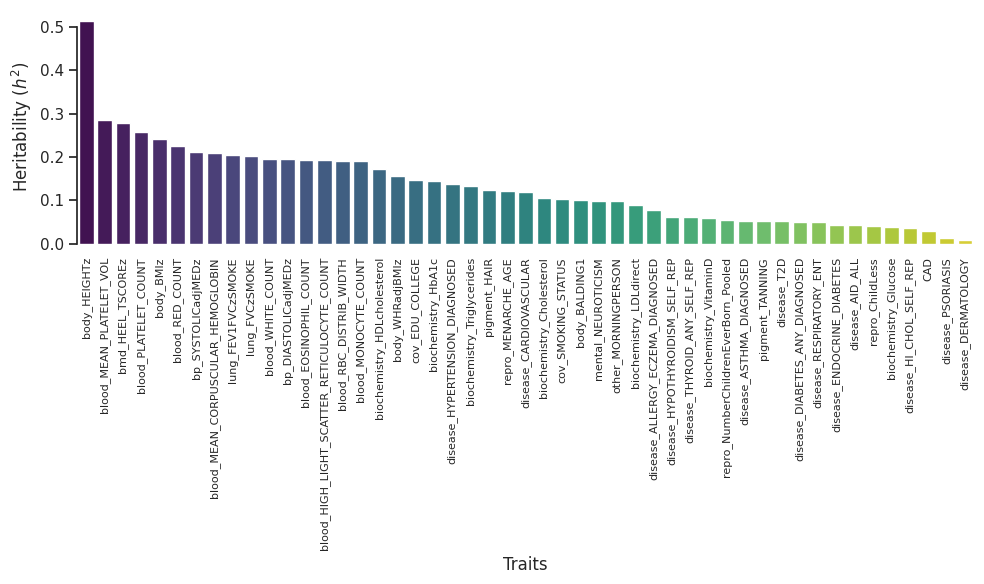

In [4]:
h2 = pd.read_csv("../data/h2.tsv", sep="\t", header=None)
plot_h2(h2)

Let's look at the $h^2$ enrichment in binary annotations for the "height" trait.

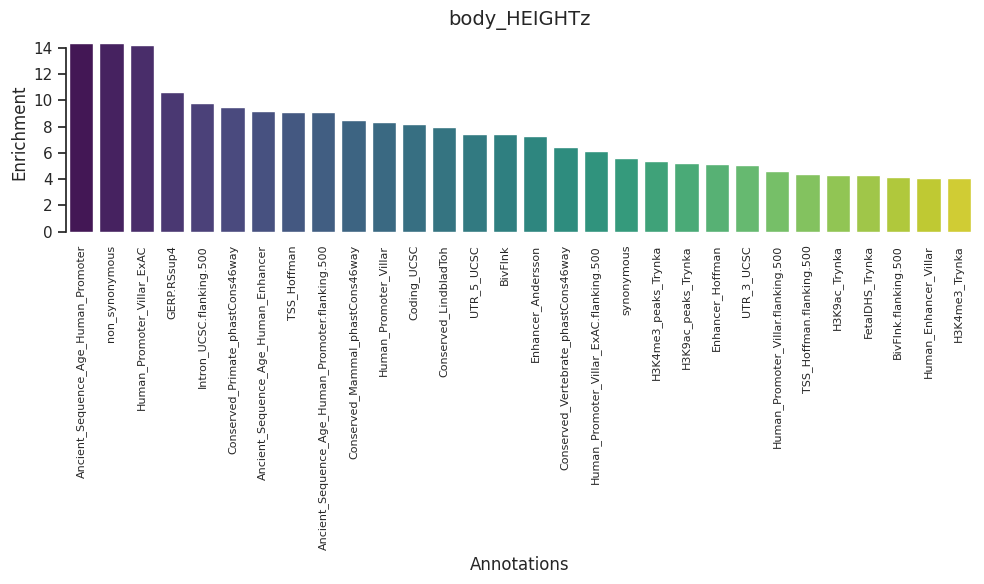

In [5]:
binary_enrichment = pd.read_csv("../data/binary_enrichment.tsv", sep="\t", index_col=0)
plot_enrichment_binary(binary_enrichment, "body_HEIGHTz", top_k=30)

Let's look at the $h^2$ enrichment in continuous annotations for the "CAD" trait. If an annotation has uniform enrichment across all 5 bins, this indicates there is no enrichment because the heritability explained is the same regardless of the value of the annotation. See Gazal et al. 2017 for more information.

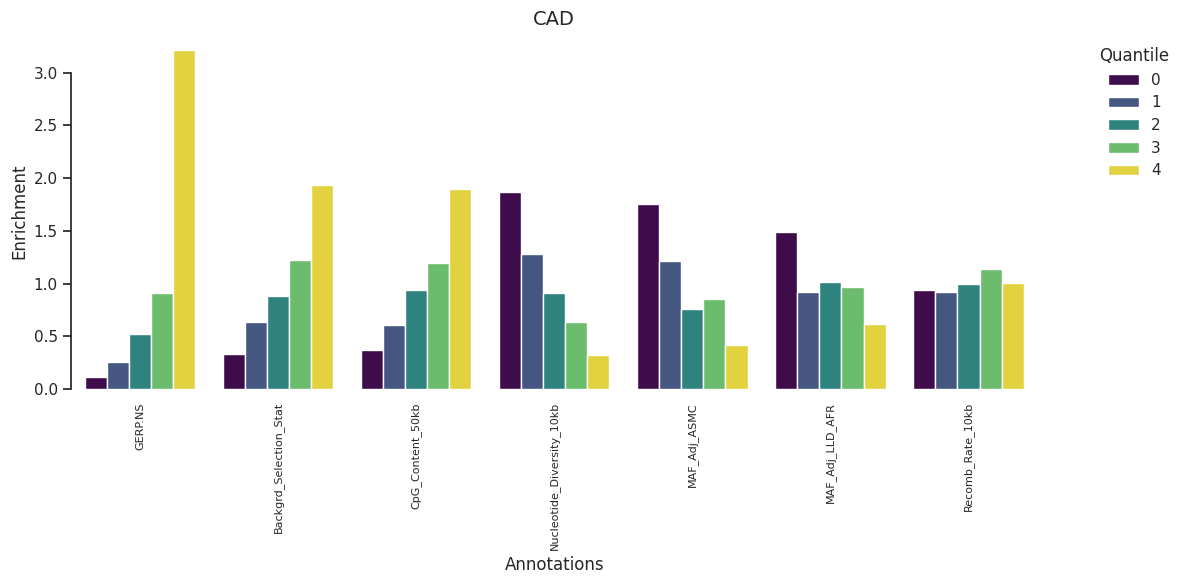

In [6]:
continuous_enrichment = pd.read_csv("../data/continuous_enrichment.tsv", sep="\t", index_col=0)
plot_enrichment_continuous(continuous_enrichment, "CAD", top_k_groups=10)